# Mean vs Median Across Aggregation Levels

This notebook compares **mean** and **median** values for the two main measurement variables in the project:
- Hindfoot length
- Weight

The goal is to see how the choice of summary statistic changes the interpretation of the data. The notebook compares mean and median at different aggregation levels, including species, genus, month, and year.

By the end of this section, you will be able to understand when the mean is useful, when the median is safer, and how comparing both values can reveal skew, outliers, or hidden differences inside grouped data.

---

## Load the data

This cell reads the merged project dataset so we can compare mean and median values for hindfoot length and weight.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../../output/merged_full.csv")
df.head()

,record_id,month,day,year,plot_id,note1,species_id,sex,hindfoot_length,weight,genus,species_name,taxa,plot_type,note1_meaning
0,63,8,19,1977,3.0,NaN,DM,M,35.0,40.0,Dipodomys,merriami,Rodent,Long-term Krat Exclosure,NaN
1,64,8,19,1977,7.0,NaN,DM,M,37.0,48.0,Dipodomys,merriami,Rodent,Rodent Exclosure,NaN
2,65,8,19,1977,4.0,NaN,DM,F,34.0,29.0,Dipodomys,merriami,Rodent,Control,NaN
3,66,8,19,1977,4.0,NaN,DM,F,35.0,46.0,Dipodomys,merriami,Rodent,Control,NaN
4,67,8,19,1977,7.0,NaN,DM,M,35.0,36.0,Dipodomys,merriami,Rodent,Rodent Exclosure,NaN


The merged dataset includes time columns, taxonomy columns, and the two measurement columns we need. The rest of the notebook narrows the dataset so the aggregation comparisons are easier to read.

## Prepare a simple measurement dataset

This cell keeps only the columns needed for the analysis. It also removes blank taxonomy values and treats non-positive measurements as missing values, since body measurements should not be zero or negative.

In [13]:
measure_df = df[['year', 'month', 'genus', 'species_name', 'taxa', 'hindfoot_length', 'weight']].copy()

for col in ['genus', 'species_name', 'taxa']:
    measure_df[col] = measure_df[col].astype('string').str.strip()

measure_df = measure_df.dropna(subset=['year', 'month', 'genus', 'species_name', 'taxa']).copy()
measure_df = measure_df.loc[
    measure_df['genus'].ne('')
    & measure_df['species_name'].ne('')
    & measure_df['taxa'].ne('')
].copy()

measure_df.loc[measure_df['hindfoot_length'] <= 0, 'hindfoot_length'] = pd.NA
measure_df.loc[measure_df['weight'] <= 0, 'weight'] = pd.NA

measure_df.head()

,year,month,genus,species_name,taxa,hindfoot_length,weight
0,1977,8,Dipodomys,merriami,Rodent,35.0,40.0
1,1977,8,Dipodomys,merriami,Rodent,37.0,48.0
2,1977,8,Dipodomys,merriami,Rodent,34.0,29.0
3,1977,8,Dipodomys,merriami,Rodent,35.0,46.0
4,1977,8,Dipodomys,merriami,Rodent,35.0,36.0


This smaller dataset keeps the analysis focused on the variables that affect the mean and median comparison. Keeping `year` and `month` also allows us to compare the statistic choice across time-based aggregations later in the notebook.

## Create a reusable mean and median summary

The next cell defines a helper function that calculates mean, median, sample size, raw mean-median gap, and percent mean-median gap for any grouping level.

The **gap** columns show how far the mean is from the median. A larger gap means the choice between mean and median changes the summary more.

In [14]:
def summarize_mean_median(data, group_cols):
    summary = (
        data.groupby(group_cols, as_index=False)
        .agg(
            n_hindfoot=('hindfoot_length', 'count'),
            mean_hindfoot_length=('hindfoot_length', 'mean'),
            median_hindfoot_length=('hindfoot_length', 'median'),
            n_weight=('weight', 'count'),
            mean_weight=('weight', 'mean'),
            median_weight=('weight', 'median'),
        )
    )

    summary['hindfoot_gap'] = summary['mean_hindfoot_length'] - summary['median_hindfoot_length']
    summary['weight_gap'] = summary['mean_weight'] - summary['median_weight']

    summary['hindfoot_percent_gap'] = (
        summary['hindfoot_gap'] / summary['median_hindfoot_length'] * 100
    )
    summary['weight_percent_gap'] = summary['weight_gap'] / summary['median_weight'] * 100

    return summary.round(2)


Using the same function for every aggregation level makes the comparisons consistent. Each table will use the same column names, so the size of the mean-median disagreement can be compared directly.

## Species-level mean vs median

Aggregating by species keeps a relatively detailed view of the data. This is useful because outliers, skew, or uneven samples are easier to detect before multiple species are combined into broader groups.

In [15]:
species_summary_df = summarize_mean_median(
    measure_df,
    ['genus', 'species_name'],
)

species_summary_df.sort_values('weight_percent_gap', key=lambda col: col.abs(), ascending=False).reset_index(drop=True)

,genus,species_name,n_hindfoot,mean_hindfoot_length,median_hindfoot_length,n_weight,mean_weight,median_weight,hindfoot_gap,weight_gap,hindfoot_percent_gap,weight_percent_gap
0,Reithrodontomys,sp.,6,18.67,19.5,6,14.17,12.5,-0.83,1.67,-4.27,13.33
1,Sigmodon,ochrognathus,40,25.60,25.0,40,55.38,49.0,0.60,6.38,2.40,13.01
2,Baiomys,taylori,383,13.26,13.0,383,9.50,9.0,0.26,0.50,1.99,5.57
3,Reithrodontomys,montanus,105,15.59,15.0,105,10.44,11.0,0.59,-0.56,3.94,-5.11
4,Chaetodipus,sp.,3,20.67,20.0,3,21.00,20.0,0.67,1.00,3.33,5.00
5,Reithrodontomys,fulvescens,79,17.54,17.0,79,13.51,13.0,0.54,0.51,3.20,3.89
6,Onychomys,sp.,5,20.40,21.0,5,21.20,22.0,-0.60,-0.80,-2.86,-3.64
7,Chaetodipus,intermedius,103,21.97,22.0,103,17.45,17.0,-0.03,0.45,-0.13,2.63
8,Reithrodontomys,megalotis,3531,16.32,16.0,3531,10.72,11.0,0.32,-0.28,1.97,-2.58
9,Perognathus,hispidus,42,24.93,25.0,42,30.21,31.0,-0.07,-0.79,-0.29,-2.53


The species-level table shows where mean and median tell a similar story and where they disagree. A large positive gap means the mean is higher than the median, which can happen when a few larger or heavier observations pull the average upward. A large negative gap means the mean is below the median, which can happen when smaller observations pull the average downward.

## Genus-level mean vs median

The same process can be repeated after grouping by genus. This produces fewer rows and is easier to scan, but it can also hide differences between species within the same genus.

In [16]:
genus_summary_df = summarize_mean_median(
    measure_df,
    ['genus'],
)

genus_summary_df.sort_values('weight_percent_gap', key=lambda col: col.abs(), ascending=False).reset_index(drop=True)

,genus,n_hindfoot,mean_hindfoot_length,median_hindfoot_length,n_weight,mean_weight,median_weight,hindfoot_gap,weight_gap,hindfoot_percent_gap,weight_percent_gap
0,Chaetodipus,29098,22.97,22.0,29098,22.49,20.0,0.97,2.49,4.40,12.44
1,Dipodomys,25100,36.90,36.0,25100,51.10,46.0,0.90,5.10,2.50,11.08
2,Baiomys,383,13.26,13.0,383,9.50,9.0,0.26,0.50,1.99,5.57
3,Perognathus,2033,15.60,15.0,2033,8.34,8.0,0.60,0.34,3.98,4.27
4,Onychomys,5655,20.00,20.0,5655,25.60,25.0,-0.00,0.60,-0.01,2.39
5,Reithrodontomys,3721,16.32,16.0,3721,10.77,11.0,0.32,-0.23,2.03,-2.07
6,Sigmodon,892,27.38,27.0,892,79.01,78.0,0.38,1.01,1.42,1.30
7,Peromyscus,4035,19.95,20.0,4035,21.79,22.0,-0.05,-0.21,-0.23,-0.94


The genus-level table shows the tradeoff of broader aggregation. Genus summaries are easier to read, but a single genus can contain species with different body sizes. When the mean and median separate at this level, it may mean that the genus contains a mixture of species or that a few observations have a strong influence on the average.

## Compare disagreement across aggregation levels

This section summarizes the average size of the mean-median gap for species and genus aggregations. Instead of focusing on one group, it compares how much disagreement exists at each aggregation level overall.

In [17]:
aggregation_gap_summary_df = pd.DataFrame([
    {
        'aggregation_level': 'Species',
        'number_of_groups': len(species_summary_df),
        'avg_abs_hindfoot_gap': species_summary_df['hindfoot_gap'].abs().mean(),
        'avg_abs_weight_gap': species_summary_df['weight_gap'].abs().mean(),
        'avg_abs_hindfoot_percent_gap': species_summary_df['hindfoot_percent_gap'].abs().mean(),
        'avg_abs_weight_percent_gap': species_summary_df['weight_percent_gap'].abs().mean(),
    },
    {
        'aggregation_level': 'Genus',
        'number_of_groups': len(genus_summary_df),
        'avg_abs_hindfoot_gap': genus_summary_df['hindfoot_gap'].abs().mean(),
        'avg_abs_weight_gap': genus_summary_df['weight_gap'].abs().mean(),
        'avg_abs_hindfoot_percent_gap': genus_summary_df['hindfoot_percent_gap'].abs().mean(),
        'avg_abs_weight_percent_gap': genus_summary_df['weight_percent_gap'].abs().mean(),
    },
])

aggregation_gap_summary_df.round(2)

,aggregation_level,number_of_groups,avg_abs_hindfoot_gap,avg_abs_weight_gap,avg_abs_hindfoot_percent_gap,avg_abs_weight_percent_gap
0,Species,24,0.33,0.90,1.63,3.11
1,Genus,8,0.44,1.31,2.07,5.01


This comparison helps show whether mean and median disagreement becomes stronger or weaker after broader aggregation. If the genus-level gap is larger, then combining species may be creating skew. If the species-level gap is larger, then the disagreement is more likely coming from outliers or uneven distributions within individual species.

## Visualize the biggest species-level disagreements

The plots below focus on the species where mean and median are farthest apart. Each line connects the median and mean for one species. Longer lines show cases where the choice of statistic changes the reported typical value more.

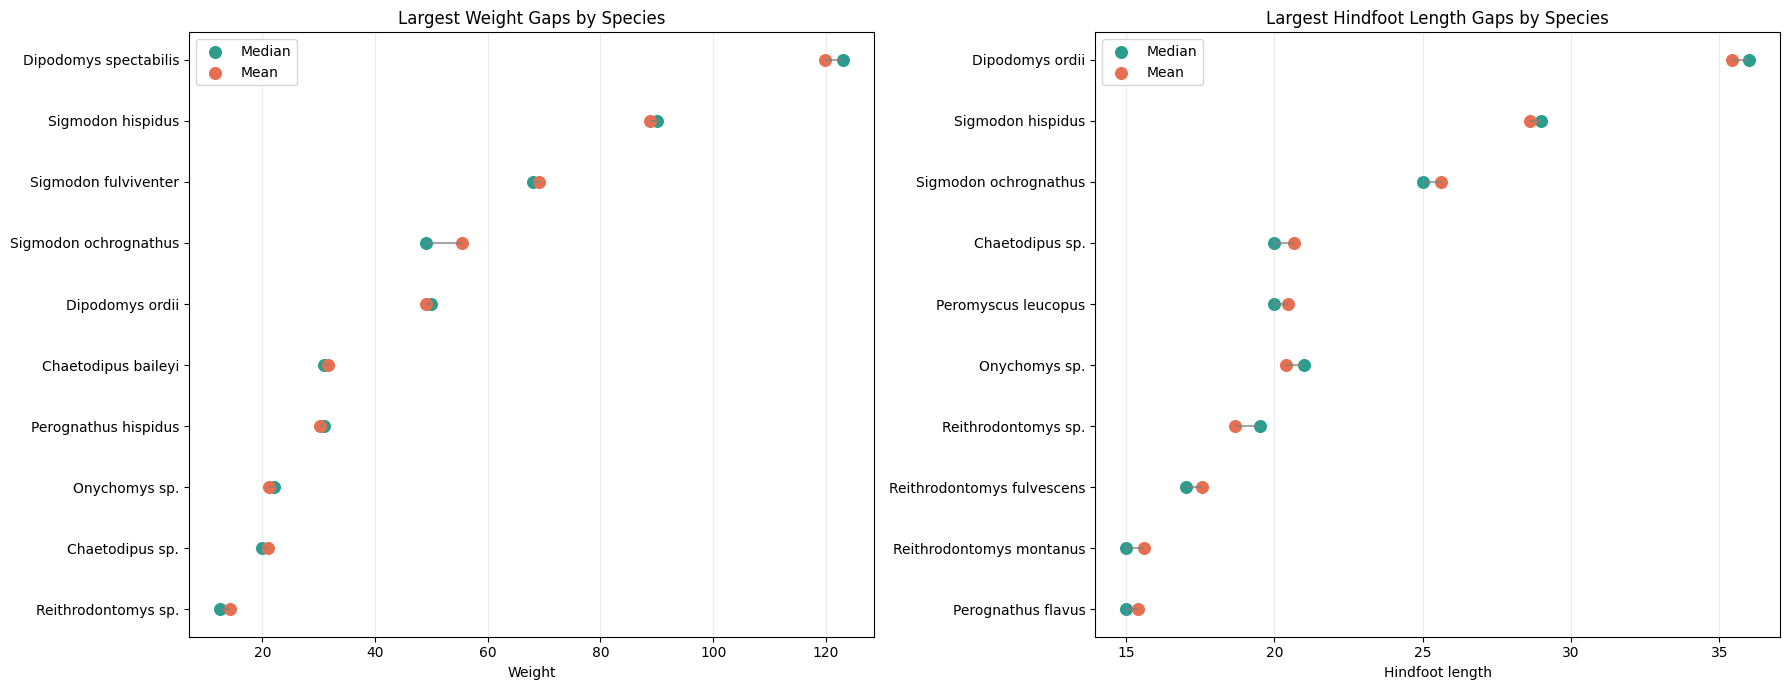

In [18]:
# FIG 3.1

top_weight_species = (
    species_summary_df.dropna(subset=['mean_weight', 'median_weight'])
    .assign(abs_gap=lambda data: data['weight_gap'].abs())
    .sort_values('abs_gap', ascending=False)
    .head(10)
    .sort_values('mean_weight')
)

top_hindfoot_species = (
    species_summary_df.dropna(subset=['mean_hindfoot_length', 'median_hindfoot_length'])
    .assign(abs_gap=lambda data: data['hindfoot_gap'].abs())
    .sort_values('abs_gap', ascending=False)
    .head(10)
    .sort_values('mean_hindfoot_length')
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, plot_df, mean_col, median_col, title, xlabel in [
    (axes[0], top_weight_species, 'mean_weight', 'median_weight', 'Largest Weight Gaps by Species', 'Weight'),
    (axes[1], top_hindfoot_species, 'mean_hindfoot_length', 'median_hindfoot_length', 'Largest Hindfoot Length Gaps by Species', 'Hindfoot length'),
]:
    labels = plot_df['genus'] + ' ' + plot_df['species_name']
    y_positions = range(len(plot_df))

    ax.hlines(y=y_positions, xmin=plot_df[median_col], xmax=plot_df[mean_col], color='gray', alpha=0.7)
    ax.scatter(plot_df[median_col], y_positions, label='Median', color='#2a9d8f', s=70)
    ax.scatter(plot_df[mean_col], y_positions, label='Mean', color='#e76f51', s=70)
    ax.set_yticks(y_positions)
    ax.set_yticklabels(labels)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(axis='x', alpha=0.25)
    ax.legend()

plt.tight_layout()
plt.show()

These visuals make the practical difference between mean and median easier to see. If a line is short, the mean and median produce almost the same interpretation. If a line is long, the data scientist should be more careful because the selected summary statistic changes the conclusion.

## Visualize genus-level mean and median values

The next plots repeat the same idea at the genus level. This view is less detailed than the species view, but it is useful for seeing whether broader aggregation creates larger gaps between mean and median.

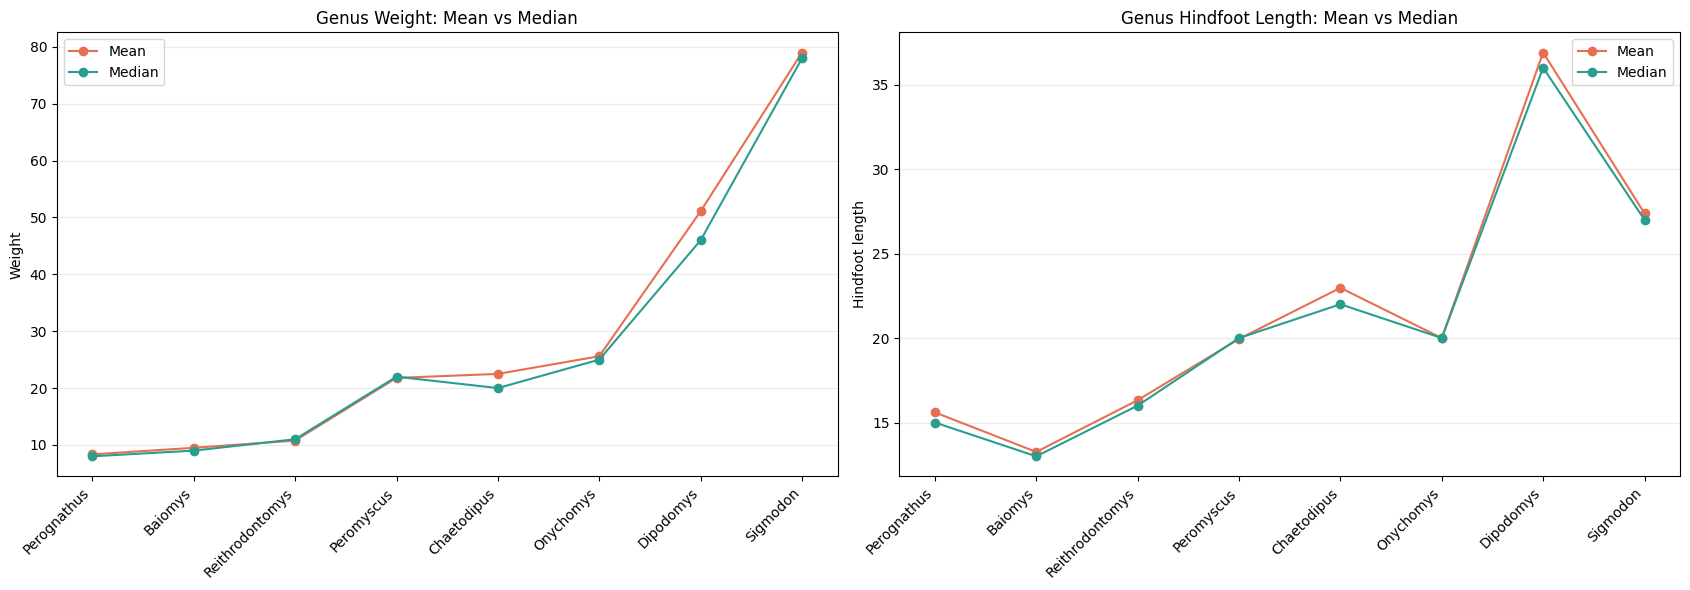

In [19]:
# FIG 3.2

genus_plot_df = genus_summary_df.sort_values('mean_weight').reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

for ax, mean_col, median_col, title, ylabel in [
    (axes[0], 'mean_weight', 'median_weight', 'Genus Weight: Mean vs Median', 'Weight'),
    (axes[1], 'mean_hindfoot_length', 'median_hindfoot_length', 'Genus Hindfoot Length: Mean vs Median', 'Hindfoot length'),
]:
    x_positions = range(len(genus_plot_df))
    ax.plot(x_positions, genus_plot_df[mean_col], marker='o', label='Mean', color='#e76f51')
    ax.plot(x_positions, genus_plot_df[median_col], marker='o', label='Median', color='#2a9d8f')
    ax.set_xticks(x_positions)
    ax.set_xticklabels(genus_plot_df['genus'], rotation=45, ha='right')
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', alpha=0.25)
    ax.legend()

plt.tight_layout()
plt.show()

At the genus level, the mean and median lines show whether the average and the typical value move together. When the lines separate, the genus may contain skewed values, outliers, or species with different measurement patterns.

## Monthly and yearly mean vs median

Mean and median can also be compared over time. Monthly aggregation keeps more short-term detail, while yearly aggregation smooths over month-to-month movement. Comparing mean and median at both levels helps show whether short-term variation is being driven by typical changes or by extreme observations.

In [20]:
monthly_summary_df = summarize_mean_median(measure_df, ['year', 'month'])
yearly_summary_df = summarize_mean_median(measure_df, ['year'])

time_gap_summary_df = pd.DataFrame([
    {
        'aggregation_level': 'Monthly',
        'number_of_groups': len(monthly_summary_df),
        'avg_abs_hindfoot_gap': monthly_summary_df['hindfoot_gap'].abs().mean(),
        'avg_abs_weight_gap': monthly_summary_df['weight_gap'].abs().mean(),
        'avg_abs_hindfoot_percent_gap': monthly_summary_df['hindfoot_percent_gap'].abs().mean(),
        'avg_abs_weight_percent_gap': monthly_summary_df['weight_percent_gap'].abs().mean(),
    },
    {
        'aggregation_level': 'Yearly',
        'number_of_groups': len(yearly_summary_df),
        'avg_abs_hindfoot_gap': yearly_summary_df['hindfoot_gap'].abs().mean(),
        'avg_abs_weight_gap': yearly_summary_df['weight_gap'].abs().mean(),
        'avg_abs_hindfoot_percent_gap': yearly_summary_df['hindfoot_percent_gap'].abs().mean(),
        'avg_abs_weight_percent_gap': yearly_summary_df['weight_percent_gap'].abs().mean(),
    },
])

time_gap_summary_df.round(2)

,aggregation_level,number_of_groups,avg_abs_hindfoot_gap,avg_abs_weight_gap,avg_abs_hindfoot_percent_gap,avg_abs_weight_percent_gap
0,Monthly,516,2.88,5.23,10.63,17.68
1,Yearly,49,2.91,5.12,11.65,17.64


This table compares short-term and long-term time aggregation. Monthly groups may show larger gaps because they preserve more local variation. Yearly groups may show smaller gaps because they smooth over monthly movement, but larger yearly gaps can still reveal years where extreme values affected the average.

## Visualize yearly weight mean and median

The plot below focuses on yearly weight because weight is more likely than hindfoot length to respond to environmental conditions, age structure, or short-term population changes.

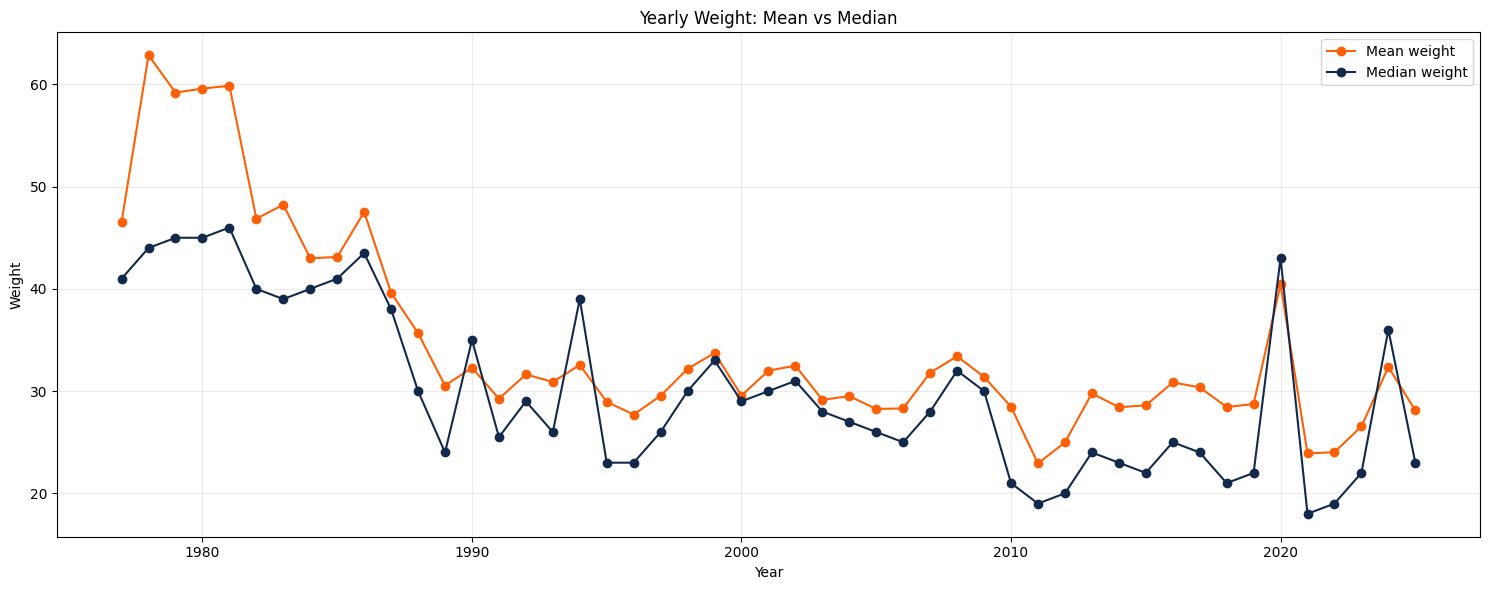

In [21]:
# FIG 3.3

fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(yearly_summary_df['year'], yearly_summary_df['mean_weight'], marker='o', label='Mean weight', color='#FF5F05')
ax.plot(yearly_summary_df['year'], yearly_summary_df['median_weight'], marker='o', label='Median weight', color='#13294B')

ax.set_title('Yearly Weight: Mean vs Median')
ax.set_xlabel('Year')
ax.set_ylabel('Weight')
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

If the mean and median follow similar paths over time, then both statistics describe the yearly pattern in a similar way. If the mean moves more sharply than the median, then a data scientist may want to inspect that year more closely because a smaller number of heavier or lighter observations may be influencing the average.

## Conclusion

- The **mean** is useful when the data is fairly balanced and the goal is to describe the overall average.
- The **median** is useful when the data may contain outliers, skew, or uneven group sizes.
- Comparing mean and median together helps identify groups where the choice of summary statistic changes the interpretation.
- Species-level aggregation keeps more detail and can reveal outliers or uneven distributions inside individual species.
- Genus-level aggregation is easier to read, but it can hide differences between species.
- Monthly aggregation preserves short-term variation, while yearly aggregation smooths that variation into a broader trend.

The strongest approach may be to calculate both mean and median first. When the two values are close, either statistic may tell a similar story. When they are far apart, the gap becomes a signal that the group deserves deeper investigation.

### TODO 

use jupyter notebook instead of py file for plots 